In [64]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [65]:
# 1. CARGA DE DATOS

bank = pd.read_csv("C:\\Users\\Alex\\Desktop\\Data Analytics Master\\PROYECTOS\\4. EDA PYTHON\\Datos_Proyecto\\bank-additional.csv", sep=",")
bank.columns = bank.columns.str.strip()  # Eliminar espacios en los nombres de las columnas

# print(bank.columns.tolist())  # Verificar los nombres de las columnas

excel_file = pd.ExcelFile("C:\\Users\\Alex\\Desktop\\Data Analytics Master\\PROYECTOS\\4. EDA PYTHON\\Datos_Proyecto\\customer-details.xlsx")
customers = pd.concat(
    [pd.read_excel(excel_file, sheet_name=sheet).assign(source_year=sheet) for sheet in excel_file.sheet_names],
    ignore_index=True
)

bank.head() # Verificar la estructura de los datos

,Unnamed: 0,age,job,marital,education,default,housing,loan,contact,duration,...,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y,date,latitude,longitude,id_
0,0,NaN,housemaid,MARRIED,basic.4y,0.0,0.0,0.0,telephone,261,...,1.1,"93,994","-36,4","4,857",5191,no,2-agosto-2019,41.495,-71.233,089b39d8-e4d0-461b-87d4-814d71e0e079
1,1,57.0,services,MARRIED,high.school,NaN,0.0,0.0,telephone,149,...,1.1,"93,994","-36,4",NaN,5191,no,14-septiembre-2016,34.601,-83.923,e9d37224-cb6f-4942-98d7-46672963d097
2,2,37.0,services,MARRIED,high.school,0.0,1.0,0.0,telephone,226,...,1.1,"93,994","-36,4","4,857",5191,no,15-febrero-2019,34.939,-94.847,3f9f49b5-e410-4948-bf6e-f9244f04918b
3,3,40.0,admin.,MARRIED,basic.6y,0.0,0.0,0.0,telephone,151,...,1.1,"93,994","-36,4",NaN,5191,no,29-noviembre-2015,49.041,-70.308,9991fafb-4447-451a-8be2-b0df6098d13e
4,4,56.0,services,MARRIED,high.school,0.0,0.0,1.0,telephone,307,...,1.1,"93,994","-36,4",NaN,5191,no,29-enero-2017,38.033,-104.463,eca60b76-70b6-4077-80ba-bc52e8ebb0eb


In [66]:
# 2. LIMPIEZA INICIAL

# Eliminar columnas irrelevantes
bank = bank.drop(columns=["Unnamed: 0"], errors="ignore")
customers = customers.drop(columns=["Unnamed: 0"], errors="ignore")

bank.head()  # Verificar la estructura después de eliminar columnas
# customers.head()  # Verificar la estructura después de eliminar columnas

,age,job,marital,education,default,housing,loan,contact,duration,campaign,...,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y,date,latitude,longitude,id_
0,NaN,housemaid,MARRIED,basic.4y,0.0,0.0,0.0,telephone,261,1,...,1.1,"93,994","-36,4","4,857",5191,no,2-agosto-2019,41.495,-71.233,089b39d8-e4d0-461b-87d4-814d71e0e079
1,57.0,services,MARRIED,high.school,NaN,0.0,0.0,telephone,149,1,...,1.1,"93,994","-36,4",NaN,5191,no,14-septiembre-2016,34.601,-83.923,e9d37224-cb6f-4942-98d7-46672963d097
2,37.0,services,MARRIED,high.school,0.0,1.0,0.0,telephone,226,1,...,1.1,"93,994","-36,4","4,857",5191,no,15-febrero-2019,34.939,-94.847,3f9f49b5-e410-4948-bf6e-f9244f04918b
3,40.0,admin.,MARRIED,basic.6y,0.0,0.0,0.0,telephone,151,1,...,1.1,"93,994","-36,4",NaN,5191,no,29-noviembre-2015,49.041,-70.308,9991fafb-4447-451a-8be2-b0df6098d13e
4,56.0,services,MARRIED,high.school,0.0,0.0,1.0,telephone,307,1,...,1.1,"93,994","-36,4",NaN,5191,no,29-enero-2017,38.033,-104.463,eca60b76-70b6-4077-80ba-bc52e8ebb0eb


In [67]:
# 3. CONVERSION DE TIPOS DE DATOS

# Columnas con coma decimal
columns_decimal = ["cons.price.idx", "cons.conf.idx", "euribor3m", "nr.employed"]

for col in columns_decimal:
    bank[col] = (
        bank[col]
        .astype(str)
        .str.replace(",", ".", regex=False)
        .replace("nan", np.nan)
    )
    bank[col] = pd.to_numeric(bank[col], errors="coerce")

# Variables binarias
for col in ["default", "housing", "loan"]:
    bank[col] = pd.to_numeric(bank[col], errors="coerce")

# Edad
bank["age"] = pd.to_numeric(bank["age"], errors="coerce")

# Fecha en español
meses = {
    "enero": "01", "febrero": "02", "marzo": "03", "abril": "04", "mayo": "05", "junio": "06",
    "julio": "07", "agosto": "08", "septiembre": "09", "octubre": "10", "noviembre": "11", "diciembre": "12"
}

def convertir_fecha_es(fecha):
    if pd.isna(fecha):
        return np.nan
    try:       
        partes = str(fecha).split("-")
        dia = partes[0]
        mes = meses[partes[1].lower()]
        año = partes[2]
        return pd.to_datetime(f"{año}-{mes}-{dia}", errors="coerce")
    except:
        return np.nan
    
bank["date"] = bank["date"].apply(convertir_fecha_es)

bank.head()  # Verificar la estructura después de la conversión de tipos

,age,job,marital,education,default,housing,loan,contact,duration,campaign,...,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y,date,latitude,longitude,id_
0,NaN,housemaid,MARRIED,basic.4y,0.0,0.0,0.0,telephone,261,1,...,1.1,93.994,-36.4,4.857,5191.0,no,2019-08-02,41.495,-71.233,089b39d8-e4d0-461b-87d4-814d71e0e079
1,57.0,services,MARRIED,high.school,NaN,0.0,0.0,telephone,149,1,...,1.1,93.994,-36.4,NaN,5191.0,no,2016-09-14,34.601,-83.923,e9d37224-cb6f-4942-98d7-46672963d097
2,37.0,services,MARRIED,high.school,0.0,1.0,0.0,telephone,226,1,...,1.1,93.994,-36.4,4.857,5191.0,no,2019-02-15,34.939,-94.847,3f9f49b5-e410-4948-bf6e-f9244f04918b
3,40.0,admin.,MARRIED,basic.6y,0.0,0.0,0.0,telephone,151,1,...,1.1,93.994,-36.4,NaN,5191.0,no,2015-11-29,49.041,-70.308,9991fafb-4447-451a-8be2-b0df6098d13e
4,56.0,services,MARRIED,high.school,0.0,0.0,1.0,telephone,307,1,...,1.1,93.994,-36.4,NaN,5191.0,no,2017-01-29,38.033,-104.463,eca60b76-70b6-4077-80ba-bc52e8ebb0eb


In [68]:
# 4. ESTANDARIZAR TEXTO
for col in ["job", "marital", "education", "contact", "poutcome", "y"]:
    bank[col] = bank[col].astype(str).str.strip().str.lower()
    bank[col] = bank[col].replace("NaN", np.nan)

bank.head()  # Verificar la estructura después de estandarizar texto

,age,job,marital,education,default,housing,loan,contact,duration,campaign,...,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y,date,latitude,longitude,id_
0,NaN,housemaid,married,basic.4y,0.0,0.0,0.0,telephone,261,1,...,1.1,93.994,-36.4,4.857,5191.0,no,2019-08-02,41.495,-71.233,089b39d8-e4d0-461b-87d4-814d71e0e079
1,57.0,services,married,high.school,NaN,0.0,0.0,telephone,149,1,...,1.1,93.994,-36.4,NaN,5191.0,no,2016-09-14,34.601,-83.923,e9d37224-cb6f-4942-98d7-46672963d097
2,37.0,services,married,high.school,0.0,1.0,0.0,telephone,226,1,...,1.1,93.994,-36.4,4.857,5191.0,no,2019-02-15,34.939,-94.847,3f9f49b5-e410-4948-bf6e-f9244f04918b
3,40.0,admin.,married,basic.6y,0.0,0.0,0.0,telephone,151,1,...,1.1,93.994,-36.4,NaN,5191.0,no,2015-11-29,49.041,-70.308,9991fafb-4447-451a-8be2-b0df6098d13e
4,56.0,services,married,high.school,0.0,0.0,1.0,telephone,307,1,...,1.1,93.994,-36.4,NaN,5191.0,no,2017-01-29,38.033,-104.463,eca60b76-70b6-4077-80ba-bc52e8ebb0eb


In [69]:
# 5. CREAR VARIABLES NUEVAS

bank["subscribed"] = bank["y"].map({"yes": 1, "no": 0})

customers["total_children"] = customers["Kidhome"] + customers["Teenhome"]

bank.head()  # Verificar la estructura después de crear nuevas variables
  

,age,job,marital,education,default,housing,loan,contact,duration,campaign,...,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y,date,latitude,longitude,id_,subscribed
0,NaN,housemaid,married,basic.4y,0.0,0.0,0.0,telephone,261,1,...,93.994,-36.4,4.857,5191.0,no,2019-08-02,41.495,-71.233,089b39d8-e4d0-461b-87d4-814d71e0e079,0
1,57.0,services,married,high.school,NaN,0.0,0.0,telephone,149,1,...,93.994,-36.4,NaN,5191.0,no,2016-09-14,34.601,-83.923,e9d37224-cb6f-4942-98d7-46672963d097,0
2,37.0,services,married,high.school,0.0,1.0,0.0,telephone,226,1,...,93.994,-36.4,4.857,5191.0,no,2019-02-15,34.939,-94.847,3f9f49b5-e410-4948-bf6e-f9244f04918b,0
3,40.0,admin.,married,basic.6y,0.0,0.0,0.0,telephone,151,1,...,93.994,-36.4,NaN,5191.0,no,2015-11-29,49.041,-70.308,9991fafb-4447-451a-8be2-b0df6098d13e,0
4,56.0,services,married,high.school,0.0,0.0,1.0,telephone,307,1,...,93.994,-36.4,NaN,5191.0,no,2017-01-29,38.033,-104.463,eca60b76-70b6-4077-80ba-bc52e8ebb0eb,0


In [70]:
customers.head()  # Verificar la estructura después de crear nuevas variables 

,Income,Kidhome,Teenhome,Dt_Customer,NumWebVisitsMonth,ID,source_year,total_children
0,161770,1,0,2012-04-04,29,089b39d8-e4d0-461b-87d4-814d71e0e079,2012,1
1,85477,1,1,2012-12-30,7,e9d37224-cb6f-4942-98d7-46672963d097,2012,2
2,147233,1,1,2012-02-02,5,3f9f49b5-e410-4948-bf6e-f9244f04918b,2012,2
3,121393,1,2,2012-12-21,29,9991fafb-4447-451a-8be2-b0df6098d13e,2012,3
4,63164,1,2,2012-06-20,20,eca60b76-70b6-4077-80ba-bc52e8ebb0eb,2012,3


In [71]:
# 6. UNION DE DATASETS

df = bank.merge(customers, left_on="id_", right_on="ID", how="left")

In [72]:
# 7. GUARDAR DATASET LIMPIO

df.to_csv("C:\\Users\\Alex\\Desktop\\Data Analytics Master\\PROYECTOS\\4. EDA PYTHON\\Datos_Proyecto\\bank_customers_clean.csv", index=False)

# print(df.info())  # Verificar la estructura final del dataset limpio
print(df.head())  # Verificar las primeras filas del dataset limpio

    age        job  marital    education  default  housing  loan    contact  \
0   NaN  housemaid  married     basic.4y      0.0      0.0   0.0  telephone   
1  57.0   services  married  high.school      NaN      0.0   0.0  telephone   
2  37.0   services  married  high.school      0.0      1.0   0.0  telephone   
3  40.0     admin.  married     basic.6y      0.0      0.0   0.0  telephone   
4  56.0   services  married  high.school      0.0      0.0   1.0  telephone   

   duration  campaign  ...                                   id_  subscribed  \
0       261         1  ...  089b39d8-e4d0-461b-87d4-814d71e0e079           0   
1       149         1  ...  e9d37224-cb6f-4942-98d7-46672963d097           0   
2       226         1  ...  3f9f49b5-e410-4948-bf6e-f9244f04918b           0   
3       151         1  ...  9991fafb-4447-451a-8be2-b0df6098d13e           0   
4       307         1  ...  eca60b76-70b6-4077-80ba-bc52e8ebb0eb           0   

   Income  Kidhome  Teenhome  Dt_Customer  N

In [73]:
############################################################################

################### ANALISIS EXPLORATORIO DE DATOS (EDA) ###################

############################################################################

In [74]:
# ESTADISTICOS DESCRIPTIVOS

num_cols = [
    "age", "duration", "campaign", "pdays", "previous", "emp.var.rate",
    "cons.price.idx", "cons.conf.idx", "euribor3m", "nr.employed", "Income", "Kidhome",
    "Teenhome","NumWebVisitsMonth" ,"total_children", "subscribed"
]

stats = df[num_cols].agg(["mean", "median", "std", "min", "max", "count"]).T.round(2)
print(stats)

                       mean    median       std      min        max    count
age                   39.98     38.00     10.44    17.00      98.00  37880.0
duration             257.74    179.00    258.67     0.00    4918.00  43000.0
campaign               2.57      2.00      2.77     1.00      56.00  43000.0
pdays                962.33    999.00    187.26     0.00     999.00  43000.0
previous               0.17      0.00      0.50     0.00       7.00  43000.0
emp.var.rate           0.08      1.10      1.57    -3.40       1.40  43000.0
cons.price.idx        93.57     93.75      0.58    92.20      94.77  42529.0
cons.conf.idx        -40.51    -41.80      4.64   -50.80     -26.90  43000.0
euribor3m              3.62      4.86      1.74     0.63       5.04  33744.0
nr.employed         5166.85   5191.00     72.41  4963.60    5228.10  43000.0
Income             93241.20  93050.50  50498.32  5841.00  180802.00  43000.0
Kidhome                1.00      1.00      0.82     0.00       2.00  43000.0

In [75]:
# CORRELACIONES

    # Analizar correlaciones entre variables numéricas y la variable objetivo "subscribed"

corr_matrix = df[num_cols].corr(numeric_only=True)
corr_subscribed = corr_matrix["subscribed"].sort_values(ascending=False).round(3)
print(corr_subscribed)

subscribed           1.000
duration             0.405
previous             0.233
cons.conf.idx        0.057
age                  0.031
NumWebVisitsMonth    0.001
Kidhome              0.000
total_children      -0.000
Teenhome            -0.001
Income              -0.005
campaign            -0.066
cons.price.idx      -0.136
emp.var.rate        -0.298
euribor3m           -0.312
pdays               -0.327
nr.employed         -0.356
Name: subscribed, dtype: float64


In [86]:
# AGRUPACIONES UTILES

######################################################################################

    # Tasa de suscripción por tipo de trabajo

job_rate = (
    df.groupby("job")["subscribed"]
    .agg(["mean", "count"])
    .sort_values("mean", ascending=False)
    .round(3)
)
print(job_rate)

######################################################################################

    # Tasa de suscripción por grupo de edad

df["age_group"] = pd.cut(
    df["age"], 
    bins=[0, 29, 39, 49, 59, 100], 
    labels=["18-29", "30-39", "40-49", "50-59", "60+"]
)

age_group_rate = (
    df.groupby("age_group", observed=True)["subscribed"]
    .agg(["mean", "count"])
    .sort_values("mean", ascending=False)
    .round(3)
)
print(age_group_rate)

######################################################################################

    # Tasa de suscripción por resultado de campaña anterior

poutcome_rate = (
    df.groupby("poutcome")["subscribed"]
    .agg(["mean", "count"])
    .sort_values("mean", ascending=False)
    .round(3)
)
print(poutcome_rate)

######################################################################################

    # Estadísticas de duración por suscripción

duration_by_sub = (
    df.groupby("subscribed")["duration"]
    .agg(["mean", "median", "std", "count"])
    .round(2)
)
print(duration_by_sub)

######################################################################################

    # Tasa de suscripción por mes de contacto

df["date"] = pd.to_datetime(df["date"], errors="coerce")

suscripcion_mes = (
    df.dropna(subset=["date", "subscribed"])
      .assign(contact_month=df["date"].dt.month)
      .groupby("contact_month")["subscribed"]
      .mean()
      .sort_index()
)

nombres_meses = {
    1: "Ene", 2: "Feb", 3: "Mar", 4: "Abr",
    5: "May", 6: "Jun", 7: "Jul", 8: "Ago",
    9: "Sep", 10: "Oct", 11: "Nov", 12: "Dic"
}

suscripcion_mes.index = suscripcion_mes.index.map(nombres_meses)

                mean  count
job                        
student        0.313    903
retired        0.252   1790
unemployed     0.144   1063
admin.         0.130  10873
management     0.112   3050
technician     0.108   7026
self-employed  0.108   1489
housemaid      0.099   1123
entrepreneur   0.083   1522
services       0.081   4162
blue-collar    0.069   9654
            mean  count
age_group              
60+        0.394   1097
18-29      0.161   5266
30-39      0.101  15609
50-59      0.101   6258
40-49      0.080   9650
              mean  count
poutcome                 
success      0.653   1436
failure      0.142   4461
nonexistent  0.088  37103
              mean  median     std  count
subscribed                               
0           220.43   163.0  207.12  38156
1           551.62   449.0  398.40   4844


In [77]:
# GRAFICOS CON MATPLOTLIB

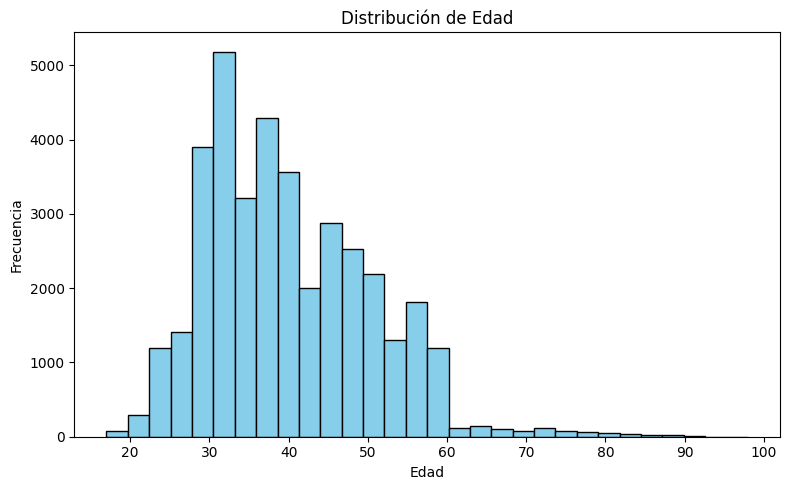

In [78]:
# 1. Histograma de edad

plt.figure(figsize=(8, 5))
df["age"].dropna().plot(kind="hist", bins=30, color="skyblue", edgecolor="black")
plt.title("Distribución de Edad")
plt.xlabel("Edad")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()

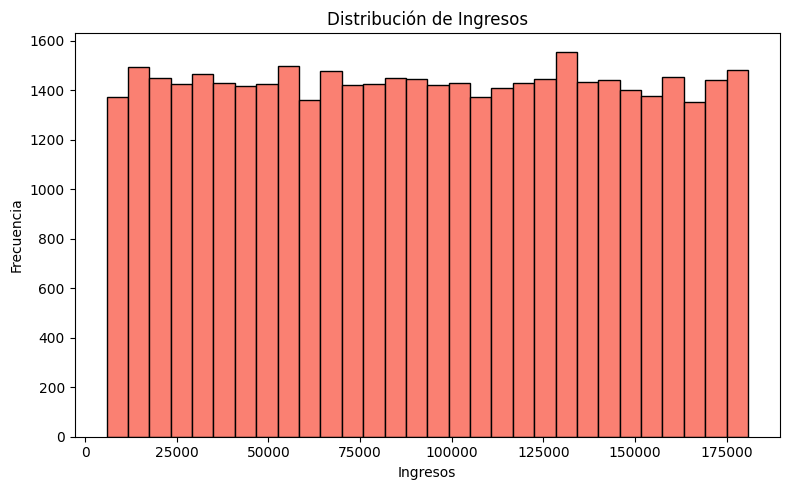

In [79]:
# 2. Histoggrama de ingresos

plt.figure(figsize=(8, 5))
df["Income"].dropna().plot(kind="hist", bins=30, color="salmon", edgecolor="black")
plt.title("Distribución de Ingresos")
plt.xlabel("Ingresos")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()

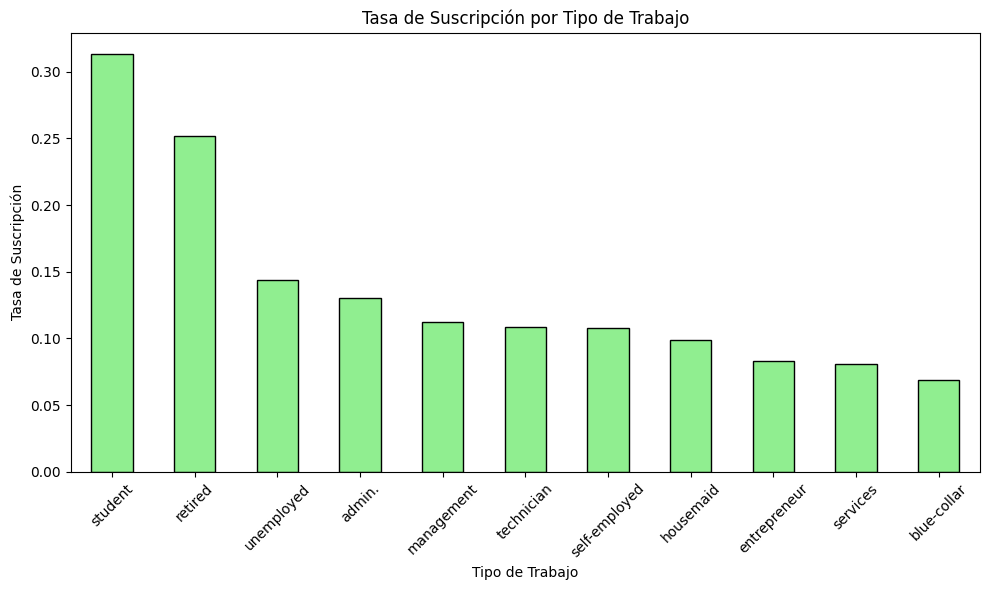

In [80]:
# 3. Tasa de suscripción por tipo de trabajo

job_rate_plot = df.groupby("job")["subscribed"].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
job_rate_plot.plot(kind="bar", color="lightgreen", edgecolor="black")
plt.title("Tasa de Suscripción por Tipo de Trabajo")
plt.xlabel("Tipo de Trabajo")
plt.ylabel("Tasa de Suscripción")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

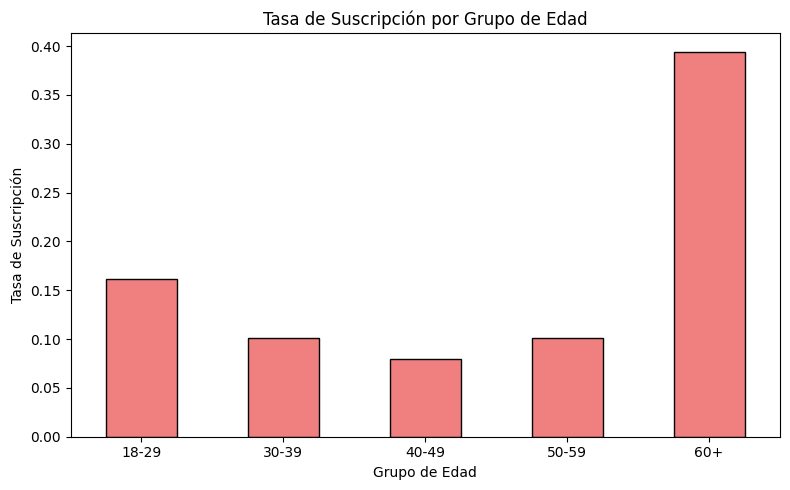

In [81]:
# 4. Tasa de suscripción por grupo de edad

age_rate_plot = df.groupby("age_group", observed=True)["subscribed"].mean()

plt.figure(figsize=(8, 5))
age_rate_plot.plot(kind="bar", color="lightcoral", edgecolor="black")
plt.title("Tasa de Suscripción por Grupo de Edad")
plt.xlabel("Grupo de Edad")
plt.ylabel("Tasa de Suscripción")
plt.xticks(rotation=0) # Necesario para mantener etiquetas horizontales
plt.tight_layout()
plt.show()

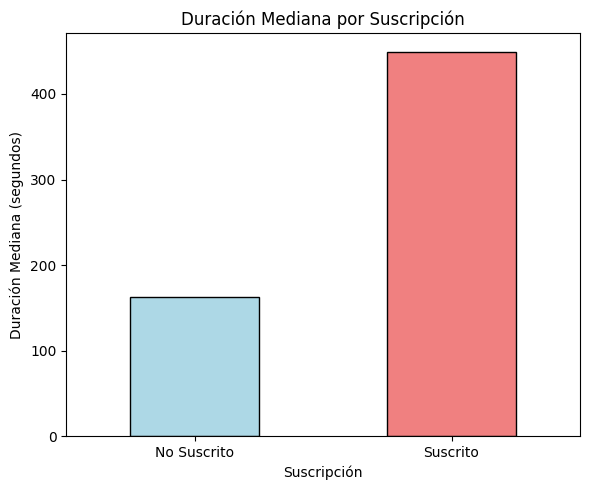

In [82]:
# 5. Duración mediana según suscripción

duration_plot = df.groupby("subscribed")["duration"].median()
duration_plot.index = duration_plot.index.map({0: "No Suscrito", 1: "Suscrito"})

plt.figure(figsize=(6, 5))
duration_plot.plot(kind="bar", color=["lightblue", "lightcoral"], edgecolor="black")
plt.title("Duración Mediana por Suscripción")
plt.xlabel("Suscripción")
plt.ylabel("Duración Mediana (segundos)")
plt.xticks(rotation=0) # Necesario para mantener etiquetas horizontales
plt.tight_layout()
plt.show()

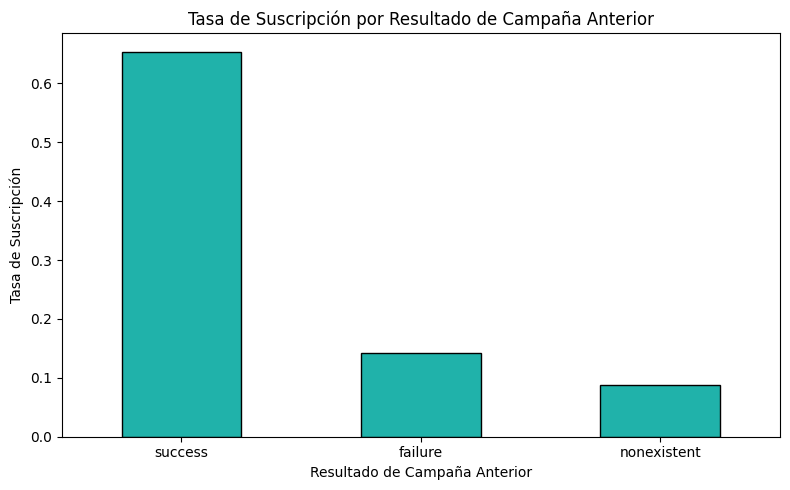

In [83]:
# 6. Tasa de suscripción por resultado de campaña anterior

poutcome_plot = df.groupby("poutcome")["subscribed"].mean().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
poutcome_plot.plot(kind="bar", color="lightseagreen", edgecolor="black")
plt.title("Tasa de Suscripción por Resultado de Campaña Anterior")
plt.xlabel("Resultado de Campaña Anterior")
plt.ylabel("Tasa de Suscripción")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

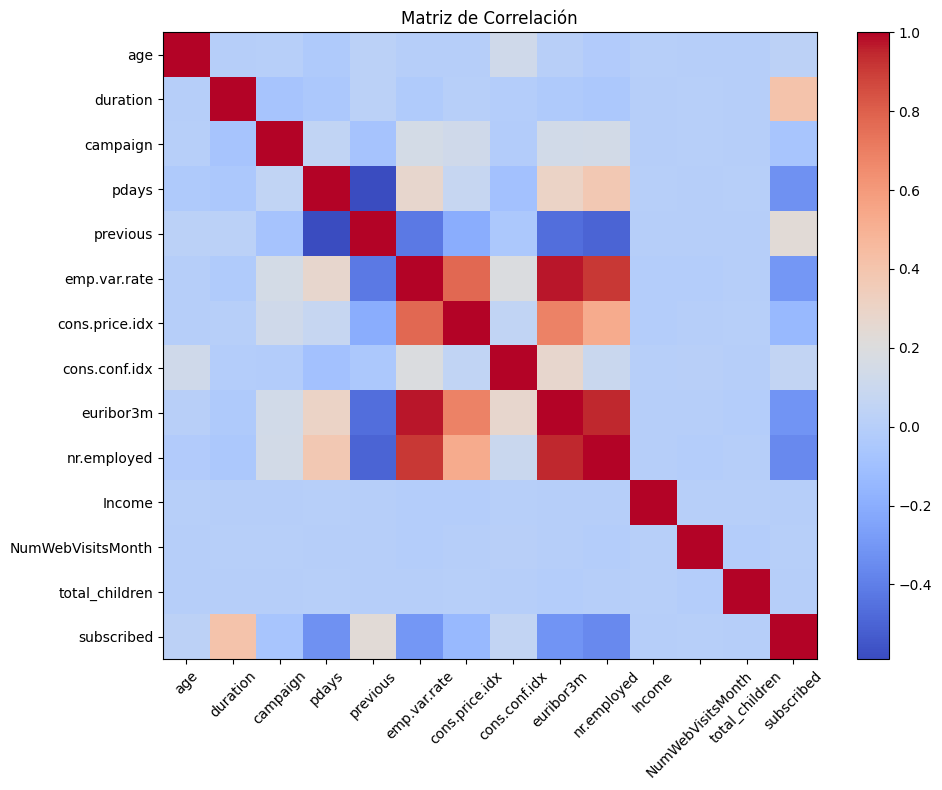

In [88]:
# 7. Heatmap de correlaciones

corr = df[
    ["age", "duration", "campaign", "pdays", "previous",
     "emp.var.rate", "cons.price.idx", "cons.conf.idx",
     "euribor3m", "nr.employed", "Income", "NumWebVisitsMonth",
     "total_children", "subscribed"]
].corr(numeric_only=True)

plt.figure(figsize=(10, 8))
plt.imshow(corr, aspect = "auto" ,cmap="coolwarm")
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Matriz de Correlación")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

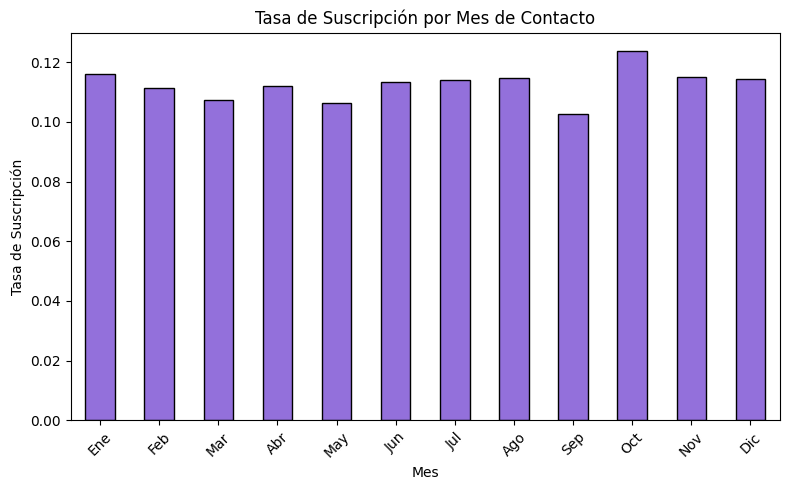

In [87]:
# 8. Suscripcion por mes de contacto

plt.figure(figsize=(8, 5))
suscripcion_mes.plot(kind="bar", color="mediumpurple", edgecolor="black")
plt.title("Tasa de Suscripción por Mes de Contacto")
plt.xlabel("Mes")
plt.ylabel("Tasa de Suscripción")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

<Figure size 800x500 with 0 Axes>

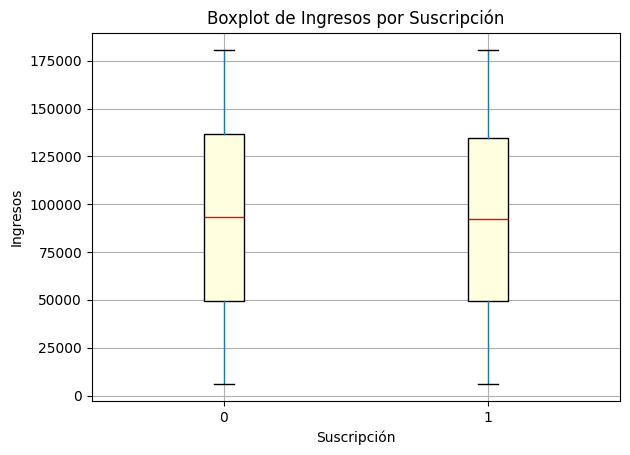

In [99]:
# 9. Boxplot de ingresos según suscripción

plt.figure(figsize=(8, 5))
df.boxplot(column="Income", by="subscribed", patch_artist=True, boxprops=dict(facecolor="lightyellow", color="black"), medianprops=dict(color="red"))
plt.title("Boxplot de Ingresos por Suscripción")
plt.suptitle("")  # Eliminar el título automático generado por boxplot
plt.xlabel("Suscripción")
plt.ylabel("Ingresos")
plt.tight_layout()
plt.show()

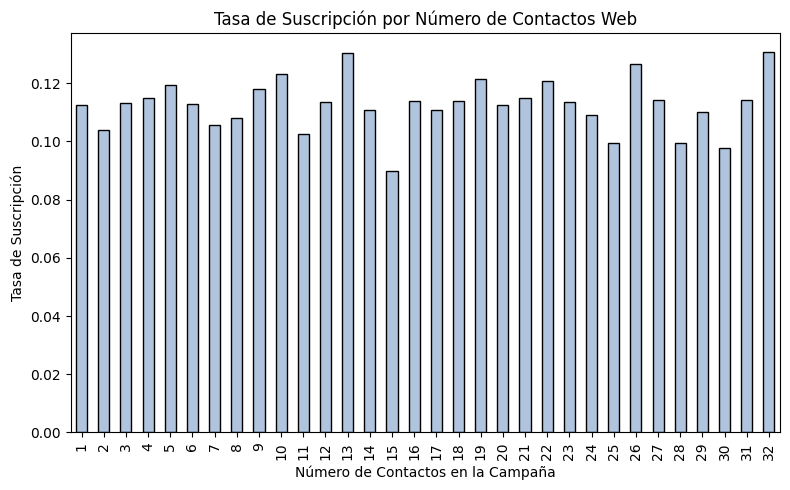

In [101]:
# 10. Numero de contactos y tasa de suscripción

contactos = (
    df.groupby("NumWebVisitsMonth")["subscribed"]
    .mean()
)

plt.figure(figsize=(8, 5))
contactos.plot(kind="bar", color="lightsteelblue", edgecolor="black")
plt.title("Tasa de Suscripción por Número de Contactos Web")
plt.xlabel("Número de Contactos en la Campaña")
plt.ylabel("Tasa de Suscripción")
plt.tight_layout()
plt.show()

Informe explicativo del análisis

En este proyecto he trabajado con dos datasets relacionados con campañas de marketing de un banco. Uno de ellos contiene la información de las llamadas y del resultado de la campaña, y el otro añade datos más generales de los clientes, como ingresos, visitas a la web o fecha de alta. La idea del análisis era entender un poco mejor qué tipo de cliente termina contratando el depósito y qué variables parecen tener más peso en esa decisión.

Lo primero fue revisar bien los datos y limpiarlos antes de empezar a sacar conclusiones. Había columnas que no servían para nada, como la típica Unnamed: 0, que he eliminado. También había variables numéricas que venían como texto y he tenido que convertirlas para poder analizarlas bien. Además, he unificado el formato de varias columnas categóricas para evitar problemas con mayúsculas, espacios o valores inconsistentes. Después de eso, he unido ambos datasets a través del identificador del cliente para trabajar con toda la información en un solo dataframe.

Una vez hecho eso, empecé con el análisis descriptivo general. A nivel de perfil, la mayoría de clientes se concentran en edades bastante normales para banca comercial, con una media cercana a los 40 años. En cuanto a la campaña, una de las primeras cosas que llama la atención es que la tasa de suscripción no es muy alta, algo lógico teniendo en cuenta que se trata de llamadas comerciales. Es decir, la mayoría de clientes contactados no terminan contratando el producto, así que resulta interesante ver qué diferencia a los que sí lo hacen.

La variable que más destaca en todo el análisis es la duración de la llamada. Se ve bastante claro que los clientes que terminan suscribiendo el depósito suelen tener llamadas mucho más largas que los que no. No creo que esto signifique simplemente que “si hablas más tiempo, vendes más”, pero sí parece indicar que cuando hay interés real por parte del cliente, la conversación se alarga más y eso acaba reflejándose en la conversión. Es una de las relaciones más claras de todo el dataset.

Otro punto bastante interesante es el historial previo del cliente. Las personas que ya habían tenido contactos anteriores o campañas previas exitosas tienen mucha más probabilidad de contratar. Aquí se nota que no todos los clientes parten del mismo punto: no responde igual alguien completamente frío que alguien que ya había mostrado interés antes o que incluso había aceptado una campaña anterior. Esta parte me parece especialmente útil desde el punto de vista del negocio, porque sugiere que el banco podría afinar mejor a quién llama y a quién no.

También he analizado la suscripción por grupos de edad y por profesión. En ambos casos salen diferencias bastante claras. Los jubilados y los estudiantes son dos de los grupos que mejor convierten, y por edad también destaca bastante el grupo de mayores. Tiene sentido pensar que ciertos perfiles pueden estar más abiertos a productos de ahorro más conservadores como este, mientras que otros quizá no tienen tanto interés o prioridad en ese momento.

Además, he incluido algunas variables del segundo dataset, como los ingresos o el número de visitas web mensuales. En estos casos no se ven relaciones tan potentes como con la duración de la llamada o el resultado de campañas anteriores, pero sí ayudan a completar el perfil del cliente. No todas las variables tienen el mismo peso, y precisamente parte del EDA consiste en eso: ver qué aporta de verdad y qué no tanto.

En la parte visual, los gráficos ayudan bastante a confirmar lo que se ve en los números. Los histogramas permiten entender mejor cómo se distribuyen variables como la edad o los ingresos, mientras que los gráficos de barras sirven para comparar de forma muy directa qué trabajos, qué meses o qué grupos de edad tienen una tasa de suscripción mayor. Los boxplots también han sido útiles para ver diferencias entre clientes que contratan y clientes que no, sobre todo en variables como ingresos o duración de llamada.

Uno de los análisis que más me ha gustado es el de la tasa de suscripción por número de contactos dentro de la campaña. Ahí se puede intuir si insistir muchas veces compensa o no. Dependiendo del comportamiento que se vea en la gráfica, puede interpretarse que a partir de cierto punto seguir llamando no mejora demasiado los resultados. Es decir, no siempre más intentos significan más conversiones, y eso puede ser importante para optimizar recursos.

En general, el análisis deja bastante claro que la suscripción no depende de un solo factor, pero sí hay variables que marcan diferencias mucho más fuertes que otras. La duración de la llamada, el historial previo del cliente y algunos perfiles concretos como jubilados o mayores de 60 años parecen estar bastante ligados a una mayor probabilidad de contratación. En cambio, otras variables aportan contexto, pero no parecen tan decisivas por sí solas.

Como conclusión, diría que este análisis sirve sobre todo para entender mejor qué está pasando detrás de la campaña y no quedarse solo con el dato final de “sí” o “no”. Más allá de describir los datos, permite sacar ideas bastante útiles: qué perfiles convierten mejor, qué señales previas conviene tener en cuenta y qué tipo de contacto parece funcionar mejor. En un caso real, esto podría ayudar a segmentar mejor las campañas y a no tratar a todos los clientes igual.